<center><img src="car.jpg" width=500></center>


Insurance companies invest a lot of time and money into optimizing their pricing and accurately estimating the likelihood that customers will make a claim. In many countries insurance it is a legal requirement to have car insurance in order to drive a vehicle on public roads, so the market is very large!

(`Source: https://www.accenture.com/_acnmedia/pdf-84/accenture-machine-leaning-insurance.pdf`) 

Knowing all of this, On the Road car insurance have requested your services in building a model to predict whether a customer will make a claim on their insurance during the policy period. As they have very little expertise and infrastructure for deploying and monitoring machine learning models, they've asked you to identify the single feature that results in the best performing model, as measured by accuracy, so they can start with a simple model in production.

They have supplied you with their customer data as a csv file called `car_insurance.csv`, along with a table detailing the column names and descriptions below.



## The dataset

| Column | Description |
|--------|-------------|
| `id` | Unique client identifier |
| `age` | Client's age: <br> <ul><li>`0`: 16-25</li><li>`1`: 26-39</li><li>`2`: 40-64</li><li>`3`: 65+</li></ul> |
| `gender` | Client's gender: <br> <ul><li>`0`: Female</li><li>`1`: Male</li></ul> |
| `driving_experience` | Years the client has been driving: <br> <ul><li>`0`: 0-9</li><li>`1`: 10-19</li><li>`2`: 20-29</li><li>`3`: 30+</li></ul> |
| `education` | Client's level of education: <br> <ul><li>`0`: No education</li><li>`1`: High school</li><li>`2`: University</li></ul> |
| `income` | Client's income level: <br> <ul><li>`0`: Poverty</li><li>`1`: Working class</li><li>`2`: Middle class</li><li>`3`: Upper class</li></ul> |
| `credit_score` | Client's credit score (between zero and one) |
| `vehicle_ownership` | Client's vehicle ownership status: <br><ul><li>`0`: Does not own their vehilce (paying off finance)</li><li>`1`: Owns their vehicle</li></ul> |
| `vehcile_year` | Year of vehicle registration: <br><ul><li>`0`: Before 2015</li><li>`1`: 2015 or later</li></ul> |
| `married` | Client's marital status: <br><ul><li>`0`: Not married</li><li>`1`: Married</li></ul> |
| `children` | Client's number of children |
| `postal_code` | Client's postal code | 
| `annual_mileage` | Number of miles driven by the client each year |
| `vehicle_type` | Type of car: <br> <ul><li>`0`: Sedan</li><li>`1`: Sports car</li></ul> |
| `speeding_violations` | Total number of speeding violations received by the client | 
| `duis` | Number of times the client has been caught driving under the influence of alcohol |
| `past_accidents` | Total number of previous accidents the client has been involved in |
| `outcome` | Whether the client made a claim on their car insurance (response variable): <br><ul><li>`0`: No claim</li><li>`1`: Made a claim</li></ul> |

### Random Forest Classification — Required Steps

1. **Import the required libraries**

   * Pandas
   * Visualization libraries
   * Scikit-learn preprocessing, pipeline, Random Forest, and evaluation tools

2. **Load the `car_insurance.csv` dataset**

   * Display the first few rows.

3. **Explore the dataset**

   * Check `shape`, `info()`, and `describe()`.
   * Check for missing values.
   * Identify numerical and categorical columns.
   * Visualize the `outcome` target distribution.

4. **Prepare features and target**

   * Create `X` containing the input features.
   * Create `y` containing `outcome`.
   * Decide whether the `id` column should be removed.

5. **Identify feature types**

   * Numerical
   * Categorical
   * Ordinal, where appropriate

6. **Preprocess the features**

   * Apply suitable encoding/transformation.
   * Organize preprocessing using `ColumnTransformer`.

7. **Split the data**

   * 80% training data.
   * 20% testing data.
   * Use `random_state`.

8. **Create a machine learning `Pipeline`**

   * Combine the `ColumnTransformer` preprocessing with `RandomForestClassifier`.

9. **Train the Random Forest**

   * Fit the pipeline using `X_train` and `y_train`.

10. **Make predictions**

    * Predict `X_test`.
    * Store the result as `y_pred`.

11. **Evaluate the model**

    * Accuracy
    * Confusion Matrix
    * Precision
    * Recall
    * F1-score
    * Classification Report

12. **Write a conclusion**

    * Explain the preprocessing performed.
    * State the model's performance.
    * Interpret the evaluation metrics.
    * Conclude how well the Random Forest predicts insurance claims.

**Overall workflow:**

`Explore → Prepare X/y → Preprocess → Split → Pipeline → Random Forest → Train → Predict → Evaluate → Conclusion`


1. **Import the required libraries**

   * Pandas
   * Visualization libraries
   * Scikit-learn preprocessing, pipeline, Random Forest, and evaluation tools

In [97]:
# Import required modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ML libraries
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report,mean_squared_error,mean_absolute_error,r2_score,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Model and split
from sklearn.model_selection import train_test_split
from scipy.stats import randint

# Start coding!

2. **Load the `car_insurance.csv` dataset**

   * Display the first few rows.

In [30]:
df = pd.read_csv('car_insurance.csv')

In [31]:
df.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


3. **Explore the dataset**

   * Check `shape`, `info()`, and `describe()`.
   * Check for missing values.
   * Identify numerical and categorical columns.
   * Visualize the `outcome` target distribution.

In [32]:
print(f'shape:{df.shape}')
print(df.info())
df.describe()

shape:(10000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis               

,id,age,gender,credit_score,vehicle_ownership,married,children,postal_code,annual_mileage,speeding_violations,duis,past_accidents,outcome
count,10000.000000,10000.000000,10000.000000,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,1.489500,0.499000,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,290030.768758,1.025278,0.500024,0.137688,0.459578,0.500022,0.463008,18915.613855,2818.434528,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.000000,0.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,1.000000,0.000000,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,1.000000,0.000000,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,2.000000,1.000000,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,3.000000,1.000000,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


In [33]:
df.isna().sum()

id                       0
age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score           982
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
postal_code              0
annual_mileage         957
vehicle_type             0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
dtype: int64

In [34]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

print(num_cols)
print(cat_cols)

['id', 'age', 'gender', 'credit_score', 'vehicle_ownership', 'married', 'children', 'postal_code', 'annual_mileage', 'speeding_violations', 'duis', 'past_accidents', 'outcome']
['driving_experience', 'education', 'income', 'vehicle_year', 'vehicle_type']


In [35]:
df.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


outcome
0.0    6867
1.0    3133
Name: count, dtype: int64
outcome
0.0    0.6867
1.0    0.3133
Name: proportion, dtype: float64


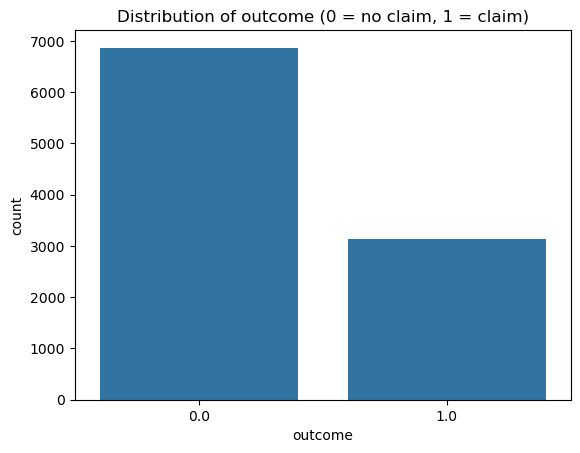

In [36]:
print(df['outcome'].value_counts())
print(df['outcome'].value_counts(normalize=True))

sns.countplot(x='outcome', data=df)
plt.title('Distribution of outcome (0 = no claim, 1 = claim)')
plt.show()

4. **Prepare features and target**

   * Create `X` containing the input features.
   * Create `y` containing `outcome`.
   * Decide whether the `id` column should be removed.

In [37]:
for col in cat_cols:
    print(col, df[col].unique())

driving_experience ['0-9y' '10-19y' '20-29y' '30y+']
education ['high school' 'none' 'university']
income ['upper class' 'poverty' 'working class' 'middle class']
vehicle_year ['after 2015' 'before 2015']
vehicle_type ['sedan' 'sports car']


In [38]:
df['postal_code'].value_counts()

postal_code
10238    6940
32765    2456
92101     484
21217     120
Name: count, dtype: int64

### From this we could see that postal code is categorical

In [39]:
X = df.drop(['id', 'outcome'], axis=1)
y = df['outcome'].astype(int)

# postal_code is a category,cast to string to keep it out of the numeric group
X['postal_code'] = X['postal_code'].astype(str)

X.shape, y.shape

((10000, 16), (10000,))


5. **Identify feature types**

   * Numerical
   * Categorical
   * Ordinal, where appropriate



In [40]:
ordinal_cols = ['driving_experience', 'education', 'income', 'vehicle_year']

ordinal_categories = [
    ['0-9y', '10-19y', '20-29y', '30y+'],
    ['none', 'high school', 'university'],
    ['poverty', 'working class', 'middle class', 'upper class'],
    ['before 2015', 'after 2015'],
]

nominal_cols = ['vehicle_type', 'postal_code']

num_cols = [c for c in X.columns if c not in ordinal_cols + nominal_cols]

print('ordinal :', ordinal_cols)
print('nominal :', nominal_cols)
print('numeric :', num_cols)

ordinal : ['driving_experience', 'education', 'income', 'vehicle_year']
nominal : ['vehicle_type', 'postal_code']
numeric : ['age', 'gender', 'credit_score', 'vehicle_ownership', 'married', 'children', 'annual_mileage', 'speeding_violations', 'duis', 'past_accidents']


In [41]:
num_trans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

ord_trans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories))
])

nom_trans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

6. **Preprocess the features**

   * Apply suitable encoding/transformation.
   * Organize preprocessing using `ColumnTransformer`.



In [42]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_trans, num_cols),
    ('ord', ord_trans, ordinal_cols),
    ('nom', nom_trans, nominal_cols)
])
preprocessor

,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


7. **Split the data**

   * 80% training data.
   * 20% testing data.
   * Use `random_state`.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1994
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 16), (2000, 16), (8000,), (2000,))

8. **Create a machine learning `Pipeline`**

   * Combine the `ColumnTransformer` preprocessing with `RandomForestClassifier`.



In [69]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=1994))
])
full_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


9. **Train the Random Forest**

   * Fit the pipeline using `X_train` and `y_train`.



In [70]:
full_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ord', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


10. **Make predictions**

    * Predict `X_test`.
    * Store the result as `y_pred`.



In [71]:
y_pred = full_pipeline.predict(X_test)
y_pred[:20]

array([0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1])

11. **Evaluate the model**

    * Accuracy
    * Confusion Matrix
    * Precision
    * Recall
    * F1-score
    * Classification Report



In [72]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy :', accuracy)
print('Precision:', precision)
print('Recall   :', recall)
print('F1-score :', f1)

Accuracy : 0.83
Precision: 0.7548845470692718
Recall   : 0.6778309409888357
F1-score : 0.7142857142857143


[[1235  138]
 [ 202  425]]


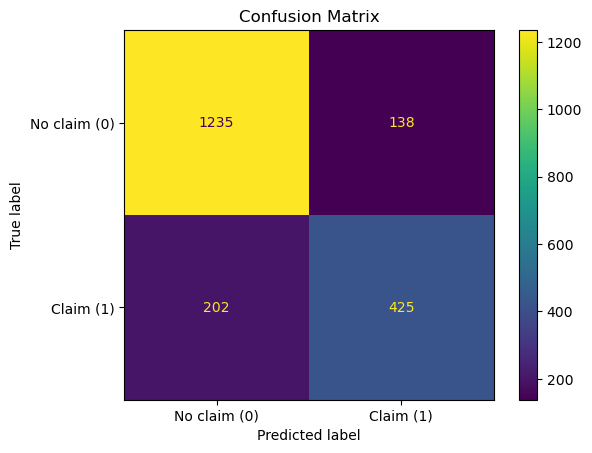

In [73]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No claim (0)', 'Claim (1)'])
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [74]:
print(classification_report(y_test, y_pred, target_names=['No claim (0)', 'Claim (1)']))

              precision    recall  f1-score   support

No claim (0)       0.86      0.90      0.88      1373
   Claim (1)       0.75      0.68      0.71       627

    accuracy                           0.83      2000
   macro avg       0.81      0.79      0.80      2000
weighted avg       0.83      0.83      0.83      2000



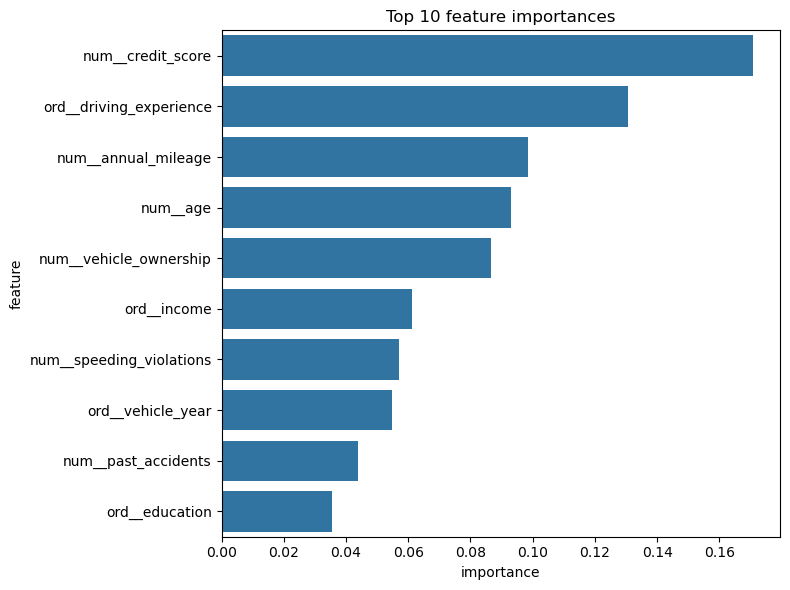

,feature,importance
2,num__credit_score,0.170927
10,ord__driving_experience,0.130481
6,num__annual_mileage,0.098472
0,num__age,0.093140
3,num__vehicle_ownership,0.086543
12,ord__income,0.061266
7,num__speeding_violations,0.057189
13,ord__vehicle_year,0.054791
9,num__past_accidents,0.043786
11,ord__education,0.035530


In [75]:
# Feature importances from the fitted forest
feature_names = full_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = full_pipeline.named_steps['classifier'].feature_importances_

importance_df = (pd.DataFrame({'feature': feature_names, 'importance': importances})
                 .sort_values('importance', ascending=False))

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(10))
plt.title('Top 10 feature importances')
plt.tight_layout()
plt.show()

importance_df.head(10)

12. **Write a conclusion**

    * Explain the preprocessing performed.
    * State the model's performance.
    * Interpret the evaluation metrics.
    * Conclude how well the Random Forest predicts insurance claims.

**Preprocessing performed**

* `id` dropped: unique identifier, no predictive value.
* `postal_code` cast to string so it is treated as a category rather than a quantity.
* Numerical columns: missing values filled with the median (`credit_score` had 982 missing, `annual_mileage` 957), then standardised.
* Ordinal columns (`driving_experience`, `education`, `income`, `vehicle_year`): encoded with `OrdinalEncoder` using an explicit category order
* Nominal columns (`vehicle_type`, `postal_code`): one-hot encoded, with `handle_unknown='ignore'`
* All steps placed inside a `ColumnTransformer` + `Pipeline`, so every transformer is fitted on the training fold only. This prevents test data from leaking into the imputation medians and the scaler statistics.

**Interpretation**
Accuracy : 0.83
Precision: 0.7548845470692718
Recall   : 0.6778309409888357
F1-score : 0.7142857142857143
* Feature importance ranks `credit_score`, `driving_experience`, `age`, `annual_mileage` and `vehicle_ownership` highest, which shows which are the most important category

**Overall**

The Random Forest predicts claims with 83% accuracy but has a low recall, which means it's not very good at spotting the correct answer yet. It is usable as a first production model. For an insurer, missing a claim (false negative) is normally costlier than a false alarm, so recall is very important to improve; class weighting, resampling, or lowering the decision threshold are the standard options.

### plot roc and auc

In [86]:
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

In [92]:
y_prob = full_pipeline.predict_proba(X_test)[:,1]

In [93]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

In [102]:
roc_auc

0.9033583428876102

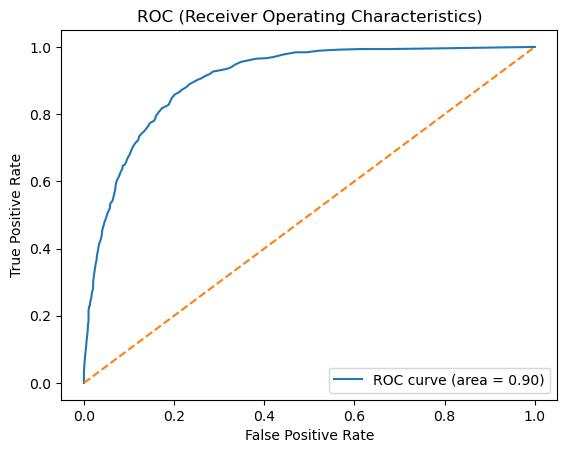

In [95]:
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC (Receiver Operating Characteristics)')
plt.legend()
plt.show()

In [100]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
param_dist = {
    'classifier__max_depth': [3,5,7,10,None],
    'classifier__min_samples_split': [2,5,10],
    'classifier__min_samples_leaf':randint(1,10),
    'classifier__criterion':["gini", "entropy", "log_loss"],
    'classifier__n_estimators':randint(50,200),
}

random_search = RandomizedSearchCV(
    estimator= full_pipeline,
    param_distributions=param_dist,
    cv=5,scoring='accuracy',random_state=42,n_jobs=-1,verbose=1
)
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,Pipeline(step...state=1994))])
,param_distributions,"{'classifier__criterion': ['gini', 'entropy', ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': <scipy.stats....t 0x3180d3950>, 'classifier__min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [101]:
random_search.best_score_

np.float64(0.85)

In [103]:
roc_auc

0.9033583428876102